
Keras Version: 2.15.0
TensorFlow Version: 2.15.0
Train shape: (60000, 785)
Test shape: (10000, 785)
Null values in train: 0
Null values in test: 0
X_train shape: (60000, 28, 28, 1)



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 fl

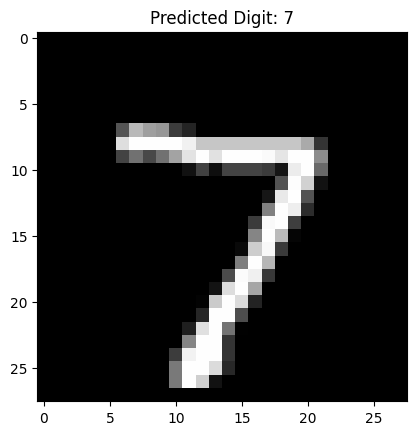

In [1]:
# ===============================
# 1. Import Libraries
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
import tensorflow
print(f"Keras Version: {keras.__version__}")
print(f"TensorFlow Version: {tensorflow.__version__}")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical


# ===============================
# 2. Load Dataset
# ===============================
train = pd.read_csv("mnist_train.csv", header=None)
test = pd.read_csv("mnist_test.csv", header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)


# ===============================
# 3. Check Null Values
# ===============================
print("Null values in train:", train.isnull().sum().sum())
print("Null values in test:", test.isnull().sum().sum())


# ===============================
# 4. Separate Features and Labels
# ===============================
X_train = train.iloc[:,1:].values
y_train = train.iloc[:,0].values

X_test = test.iloc[:,1:].values
y_test = test.iloc[:,0].values


# ===============================
# 5. Normalize Pixel Values
# ===============================
X_train = X_train / 255.0
X_test = X_test / 255.0


# ===============================
# 6. Reshape for CNN
# ===============================
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

print("X_train shape:", X_train.shape)


# ===============================
# 7. One Hot Encoding
# ===============================
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)


# ===============================
# 8. Build CNN Model
# ===============================
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

# Convolution Layer 2
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128,activation='relu'))

# Output Layer
model.add(Dense(10,activation='softmax'))


# ===============================
# 9. Compile Model
# ===============================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# ===============================
# 10. Train Model
# ===============================
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test,y_test)
)


# ===============================
# 11. Evaluate Model
# ===============================
loss,accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:", accuracy)


# ===============================
# 12. Prediction Example
# ===============================
pred = model.predict(X_test)

digit = np.argmax(pred[0])
print("Predicted Digit:", digit)


# ===============================
# 13. Show Image
# ===============================
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title("Predicted Digit: " + str(digit))
plt.show()

In [2]:
# ===============================
# 14. Save Model
# ===============================
model.save("mnist_cnn_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


C:\Users\admin\AppData\Roaming\Python\Python310\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
